# **Ejercicio 09: Multimodal Embeddings**
---
- Nombre: Michael Enríquez
- Fecha: Martes 13 de julio, 2026
---
**Objetivo de la práctica**
El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

Pasos:
- Obtener embeddings de imágenes y textos con CLIP.
- Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
- Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
- Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

### Etapa 1: Dependencias y librerias

In [1]:
!pip install -q torch torchvision transformers pillow matplotlib scikit-learn pandas

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from transformers import CLIPProcessor, CLIPModel

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import transformers

### Etapa 2: Modelo CLIP y preparación de los datos

In [3]:
# Cargar modelo CLIP

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

c:\Users\Michael\Documents\7mo\RI-2026\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Michael\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 33946.09it/s]


In [4]:
# Cargar imágenes

image_folder = "imagenes"

image_files = sorted(os.listdir(image_folder))

images = [
    Image.open(os.path.join(image_folder, img)).convert("RGB")
    for img in image_files
]

print(image_files)

['Arbol.jpg', 'dab.jpg', 'faro.jpg', 'humano.jpg', 'nube.jpg', 'perro.jpg', 'playa.jpg', 'sol.jpg']


In [5]:
texts = [
    "a pink tree next to a river",
    "a cartoon of a human child doing a dab",
    "A white lighthouse on an island beach",
    "a human man named Cristobal Colon",
    "a cartoon of a sun behind a cloud",
    "a dog",
    "the silhouette of a human on the beach",
    "a caricature of a sun"
]

### Etapa 3: Embeddings

In [17]:
# Embeddings de imágenes
inputs = processor(images=images, return_tensors="pt").to(device)

with torch.no_grad():
    vision_outputs = model.vision_model(pixel_values=inputs["pixel_values"])
    image_embeddings = model.visual_projection(vision_outputs.pooler_output)

# Normalización L2
image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

image_embeddings = image_embeddings.cpu().numpy()

In [18]:
# Embeddings de texto
inputs = processor(text=texts, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    text_outputs = model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )
    text_embeddings = model.text_projection(text_outputs.pooler_output)

# Normalización L2
text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

text_embeddings = text_embeddings.cpu().numpy()

Verificamos el Espacio Vectorial

In [19]:
print("Dimensión embeddings de imágenes:", image_embeddings.shape)
print("Dimensión embeddings de texto:", text_embeddings.shape)

Dimensión embeddings de imágenes: (8, 512)
Dimensión embeddings de texto: (8, 512)


### Etapa 4: Visualización mediante PCA

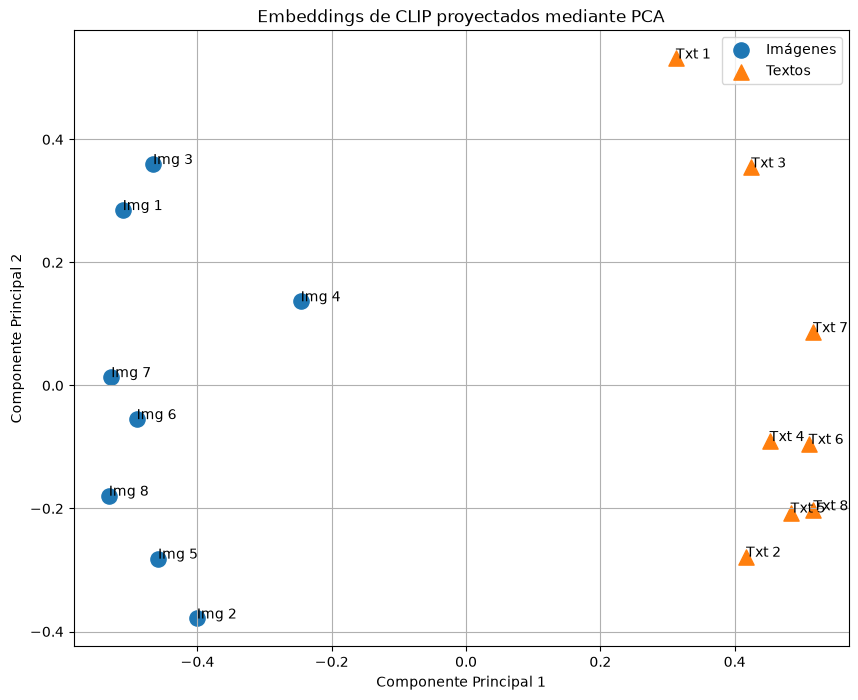

In [21]:
# Unir embeddings
all_embeddings = np.vstack((image_embeddings, text_embeddings))

# Creamos las etiquetas
labels = (
    [f"Img {i+1}" for i in range(len(image_files))]
    +
    [f"Txt {i+1}" for i in range(len(texts))]
)

# Aplicamos PCA
pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(all_embeddings)

# Graficamos 
plt.figure(figsize=(10,8))

n = len(image_files)

plt.scatter(
    embeddings_2d[:n,0],
    embeddings_2d[:n,1],
    s=120,
    label="Imágenes"
)

plt.scatter(
    embeddings_2d[n:,0],
    embeddings_2d[n:,1],
    marker="^",
    s=120,
    label="Textos"
)

for i, label in enumerate(labels):
    plt.text(
        embeddings_2d[i,0],
        embeddings_2d[i,1],
        label
    )

plt.title("Embeddings de CLIP proyectados mediante PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True)

plt.show()

### Etapa 5:Emparejamiento mediante Cosine Similarity

In [22]:
similarity = cosine_similarity(text_embeddings, image_embeddings)
print(similarity)

[[0.3322416  0.09293553 0.17388925 0.12254221 0.13255364 0.09559712
  0.13608092 0.12767982]
 [0.14990366 0.33317304 0.10612492 0.13793403 0.20214954 0.15035078
  0.24088094 0.22367802]
 [0.20322847 0.11074173 0.2970662  0.10862568 0.18268147 0.13682315
  0.17149702 0.14907086]
 [0.17672408 0.23337793 0.19009961 0.30592144 0.20727712 0.15449974
  0.21019125 0.20296158]
 [0.19029124 0.20637666 0.16573524 0.1793493  0.33844215 0.16343592
  0.20737565 0.2905097 ]
 [0.1916514  0.23487382 0.17353308 0.1813782  0.24500737 0.24809316
  0.18555436 0.21042663]
 [0.16552341 0.13809651 0.20163113 0.14285739 0.16585626 0.14106947
  0.24459216 0.17688027]
 [0.19749123 0.22186327 0.16423516 0.20222673 0.2773632  0.18599096
  0.212608   0.30293226]]


Texto => Imagen

In [ ]:
print("Texto => Imagen\n")

for i, text in enumerate(texts):

    idx = np.argmax(similarity[i])

    print(f'Texto: "{text}"')
    print(f"Imagen encontrada: {image_files[idx]}")
    print(f"Similitud: {similarity[i, idx]:.4f}")
    print()

=== Texto → Imagen ===

Texto: "a pink tree next to a river"
Imagen encontrada: Arbol.jpg
Similitud: 0.3322

Texto: "a cartoon of a human child doing a dab"
Imagen encontrada: dab.jpg
Similitud: 0.3332

Texto: "A white lighthouse on an island beach"
Imagen encontrada: faro.jpg
Similitud: 0.2971

Texto: "a human man named Cristobal Colon"
Imagen encontrada: humano.jpg
Similitud: 0.3059

Texto: "a cartoon of a sun behind a cloud"
Imagen encontrada: nube.jpg
Similitud: 0.3384

Texto: "a dog"
Imagen encontrada: perro.jpg
Similitud: 0.2481

Texto: "the silhouette of a human on the beach"
Imagen encontrada: playa.jpg
Similitud: 0.2446

Texto: "a caricature of a sun"
Imagen encontrada: sol.jpg
Similitud: 0.3029



Imagen => Texto

In [24]:
similarity_inv = cosine_similarity(image_embeddings, text_embeddings)

print("=== Imagen → Texto ===\n")

for i, image in enumerate(image_files):

    idx = np.argmax(similarity_inv[i])

    print(f"Imagen: {image}")
    print(f"Texto encontrado: {texts[idx]}")
    print(f"Similitud: {similarity_inv[i, idx]:.4f}")
    print()

=== Imagen → Texto ===

Imagen: Arbol.jpg
Texto encontrado: a pink tree next to a river
Similitud: 0.3322

Imagen: dab.jpg
Texto encontrado: a cartoon of a human child doing a dab
Similitud: 0.3332

Imagen: faro.jpg
Texto encontrado: A white lighthouse on an island beach
Similitud: 0.2971

Imagen: humano.jpg
Texto encontrado: a human man named Cristobal Colon
Similitud: 0.3059

Imagen: nube.jpg
Texto encontrado: a cartoon of a sun behind a cloud
Similitud: 0.3384

Imagen: perro.jpg
Texto encontrado: a dog
Similitud: 0.2481

Imagen: playa.jpg
Texto encontrado: the silhouette of a human on the beach
Similitud: 0.2446

Imagen: sol.jpg
Texto encontrado: a caricature of a sun
Similitud: 0.3029



Matriz de similitud

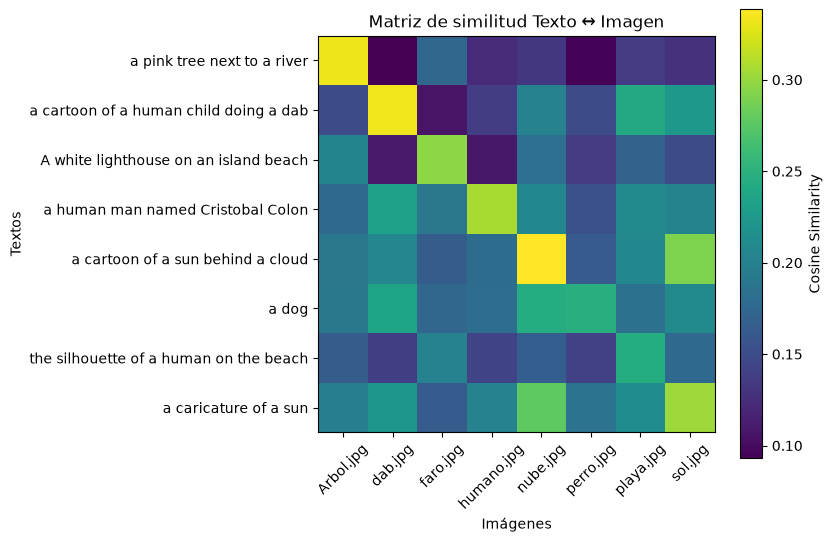

In [25]:
plt.figure(figsize=(8,6))

plt.imshow(similarity, cmap="viridis")
plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(image_files)), image_files, rotation=45)
plt.yticks(range(len(texts)), texts)

plt.xlabel("Imágenes")
plt.ylabel("Textos")
plt.title("Matriz de similitud Texto ↔ Imagen")

plt.tight_layout()
plt.show()

### Etapa 6: Busqueda

In [33]:
def buscar(query, top_k=3):

    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        text_outputs = model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        query_embedding = model.text_projection(text_outputs.pooler_output)

    # Normalizar
    query_embedding = query_embedding / query_embedding.norm(dim=-1, keepdim=True)

    query_embedding = query_embedding.cpu().numpy()

    # Similaridades
    sim_images = cosine_similarity(query_embedding, image_embeddings)[0]
    sim_texts = cosine_similarity(query_embedding, text_embeddings)[0]

    # Top resultados
    top_images = np.argsort(sim_images)[::-1][:top_k]
    top_texts = np.argsort(sim_texts)[::-1][:top_k]

    print("="*60)
    print("Consulta:", query)
    print("="*60)

    print("\nImágenes más similares\n")

    for idx in top_images:
        print(f"{image_files[idx]}  ({sim_images[idx]:.4f})")

    print("\nTextos más similares\n")

    for idx in top_texts:
        print(f"{texts[idx]}  ({sim_texts[idx]:.4f})")

    # Mostrar mejor imagen
    mejor = top_images[0]

    plt.figure(figsize=(15,5))

    for i, idx in enumerate(top_images):

        plt.subplot(1, top_k, i+1)
        plt.imshow(images[idx])
        plt.axis("off")
        plt.title(f"{sim_images[idx]:.3f}")

    plt.tight_layout()
    plt.show()

Consulta: tree and a river

Imágenes más similares

Arbol.jpg  (0.2742)
faro.jpg  (0.1611)
playa.jpg  (0.1472)

Textos más similares

a pink tree next to a river  (0.8135)
a dog  (0.6223)
A white lighthouse on an island beach  (0.5950)


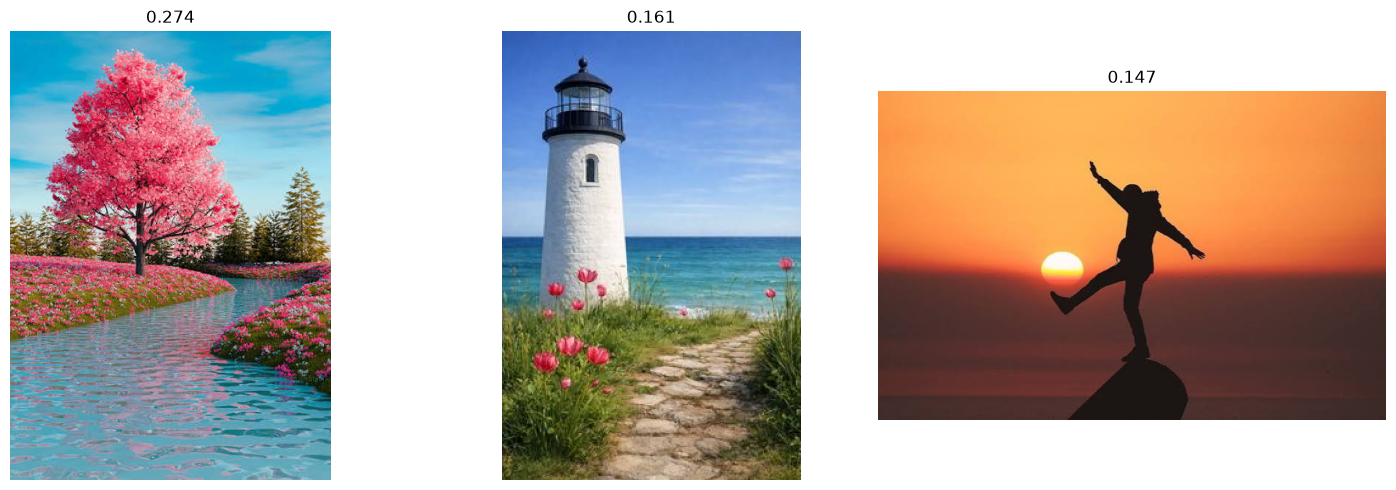

In [35]:
buscar("tree and a river")